In [1]:
import os
import re
import shutil
import pandas as pd
import plotnine as pln
from statsmodels.formula.api import ols

In [2]:
def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation)
    if parts:
        wt, site, mut = parts.groups()
        return [wt, int(site), mut]
    else:
        return [None, None, None]
    
split_mut_sit('H2T')

['H', 2, 'T']

In [3]:
dir_path = '../data/DMS_ProteinGym_substitutions/'
path_multiples = os.path.join(dir_path, 'multiples')
path_singles = os.path.join(dir_path, 'singles')

os.makedirs(path_multiples, exist_ok=True)
os.makedirs(path_singles, exist_ok=True)

for file in os.listdir(dir_path):
    if file.endswith('.csv'):
        data = pd.read_csv(f'{dir_path}/{file}')
        # check if mutantation do not match letter-digit-letter
        invalid = ~data['mutant'].astype(str).str.match(r'^[A-Z]\d+[A-Z]$')
        
        if invalid.any():
            print(f"{file} has multiple mutants:")
            shutil.move(os.path.join(dir_path, file), os.path.join(path_multiples, file))
        else:
            shutil.move(os.path.join(dir_path, file), os.path.join(path_singles, file))


## Relative variability of site means

In [4]:
res_dict = {'Dataset':[], 'RVSM':[]}

dir_path = f'../data/DMS_ProteinGym_substitutions/singles/'
for file in os.listdir(dir_path):
    data = pd.read_csv(f'{dir_path}/{file}')
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    
    # equation
    total_std = data['DMS_score'].std()
    grouped_data = data.groupby(['site'], as_index=False, observed=True)['DMS_score'].mean()
    sd_sites = grouped_data['DMS_score'].std()
    variance = sd_sites / total_std

    res_dict['Dataset'].append(file.replace('.csv', ''))
    res_dict['RVSM'].append(variance)

RVSM = pd.DataFrame.from_dict(res_dict)
RVSM

,Dataset,RVSM
0,CD19_HUMAN_Klesmith_2019_FMC_singles,0.654095
1,VRPI_BPT7_Tsuboyama_2023_2WNM,0.801616
2,IF1_ECOLI_Kelsic_2016,0.742369
3,ENV_HV1BR_Haddox_2016,0.199678
4,A0A192B1T2_9HIV1_Haddox_2018,0.829449
...,...,...
143,PTEN_HUMAN_Matreyek_2021,0.748610
144,BLAT_ECOLX_Jacquier_2013,0.789535
145,BLAT_ECOLX_Stiffler_2015,0.796036
146,SRC_HUMAN_Ahler_2019,0.797888


In [6]:
RVSM_dict = {}
for idx, col in RVSM.iterrows():
    RVSM_dict[col['Dataset']] = col['RVSM']

## Fraction of highly variable sites

In [7]:
cutoff = 0.7
res_dict = {'Dataset':[], 'FHVS':[]}

dir_path = f'../data/DMS_ProteinGym_substitutions/singles/'
for file in os.listdir(dir_path):
    data = pd.read_csv(f'{dir_path}/{file}')
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    
    # equation
    global_std = data['DMS_score'].std()
    grouped_data = data.groupby('site', as_index=False, observed=True)['DMS_score'].std().fillna(0)
    grouped_data['FHVS'] = grouped_data['DMS_score'] / global_std
    sites = list(grouped_data.query(f'FHVS > {cutoff}')['site'].values)
    data = data.query('site in @sites')
    fraction = len(sites)/grouped_data.shape[0] # frac=part/total

    res_dict['Dataset'].append(file.replace('.csv', ''))
    res_dict['FHVS'].append(fraction)

FHVS = pd.DataFrame.from_dict(res_dict)
FHVS

,Dataset,FHVS
0,CD19_HUMAN_Klesmith_2019_FMC_singles,0.452206
1,VRPI_BPT7_Tsuboyama_2023_2WNM,0.232143
2,IF1_ECOLI_Kelsic_2016,0.277778
3,ENV_HV1BR_Haddox_2016,0.605613
4,A0A192B1T2_9HIV1_Haddox_2018,0.179758
...,...,...
143,PTEN_HUMAN_Matreyek_2021,0.449086
144,BLAT_ECOLX_Jacquier_2013,0.338403
145,BLAT_ECOLX_Stiffler_2015,0.330798
146,SRC_HUMAN_Ahler_2019,0.292683


In [9]:
FHVS_dict = {}
for idx, col in FHVS.iterrows():
    FHVS_dict[col['Dataset']] = col['FHVS']

## Supervised results

In [14]:
doubles_list = os.listdir('../data/DMS_ProteinGym_substitutions/multiples')
doubles_list = [file.strip('.csv') for file in doubles_list ]

res = pd.read_csv('../data/DMS_supervised_substitutions_merged_scores.csv')
res = res.query('DMS_id not in @doubles_list ')

res['FHVS'] = res['DMS_id'].map(FHVS_dict)
res['RVSM'] = res['DMS_id'].map(RVSM_dict)

res

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM
0,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_contiguous_5,0.012776,1.311910,0.234127,0.522487
1,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_modulo_5,0.163152,1.001697,0.234127,0.522487
2,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_random_5,0.232439,0.933645,0.234127,0.522487
3,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - MSA Transformer,fold_contiguous_5,0.429282,1.061674,0.234127,0.522487
4,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - MSA Transformer,fold_modulo_5,0.439994,0.937845,0.234127,0.522487
...,...,...,...,...,...,...,...
7057,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Not augmented,fold_modulo_5,0.048886,1.017848,0.232143,0.801616
7058,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Not augmented,fold_random_5,0.728991,0.673653,0.232143,0.801616
7059,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_contiguous_5,0.634364,0.570359,0.232143,0.801616
7060,VRPI_BPT7_Tsuboyama_2023_2WNM,ProteinNPT,fold_modulo_5,0.693476,0.483393,0.232143,0.801616


In [ ]:
#res.to_csv('../experiments/compiled_results/protein_gym_plus_var_res.csv')

# plot results

In [35]:
res = pd.read_csv('../experiments/compiled_results/protein_gym_plus_var_res.csv', index_col=0)
res = res.query('fold_variable_name == "fold_random_5"').copy()
res

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM
2,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - ESM1v,fold_random_5,0.232439,0.933645,0.234127,0.522487
5,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - MSA Transformer,fold_random_5,0.439006,0.912103,0.234127,0.522487
8,A0A140D2T1_ZIKV_Sourisseau_2019,Embeddings - Augmented - Tranception,fold_random_5,0.482941,0.854068,0.234127,0.522487
11,A0A140D2T1_ZIKV_Sourisseau_2019,Kermut,fold_random_5,0.585255,0.776758,0.234127,0.522487
14,A0A140D2T1_ZIKV_Sourisseau_2019,OHE - Augmented - DeepSequence,fold_random_5,0.138202,1.012760,0.234127,0.522487
...,...,...,...,...,...,...,...
7049,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Augmented - MSA Transformer,fold_random_5,0.606187,0.607334,0.232143,0.801616
7052,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Augmented - TranceptEVE,fold_random_5,0.658348,0.746992,0.232143,0.801616
7055,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Augmented - Tranception,fold_random_5,0.677994,0.749584,0.232143,0.801616
7058,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Not augmented,fold_random_5,0.728991,0.673653,0.232143,0.801616


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'fill' aesthetic. Make sure you have mapped a variable to it


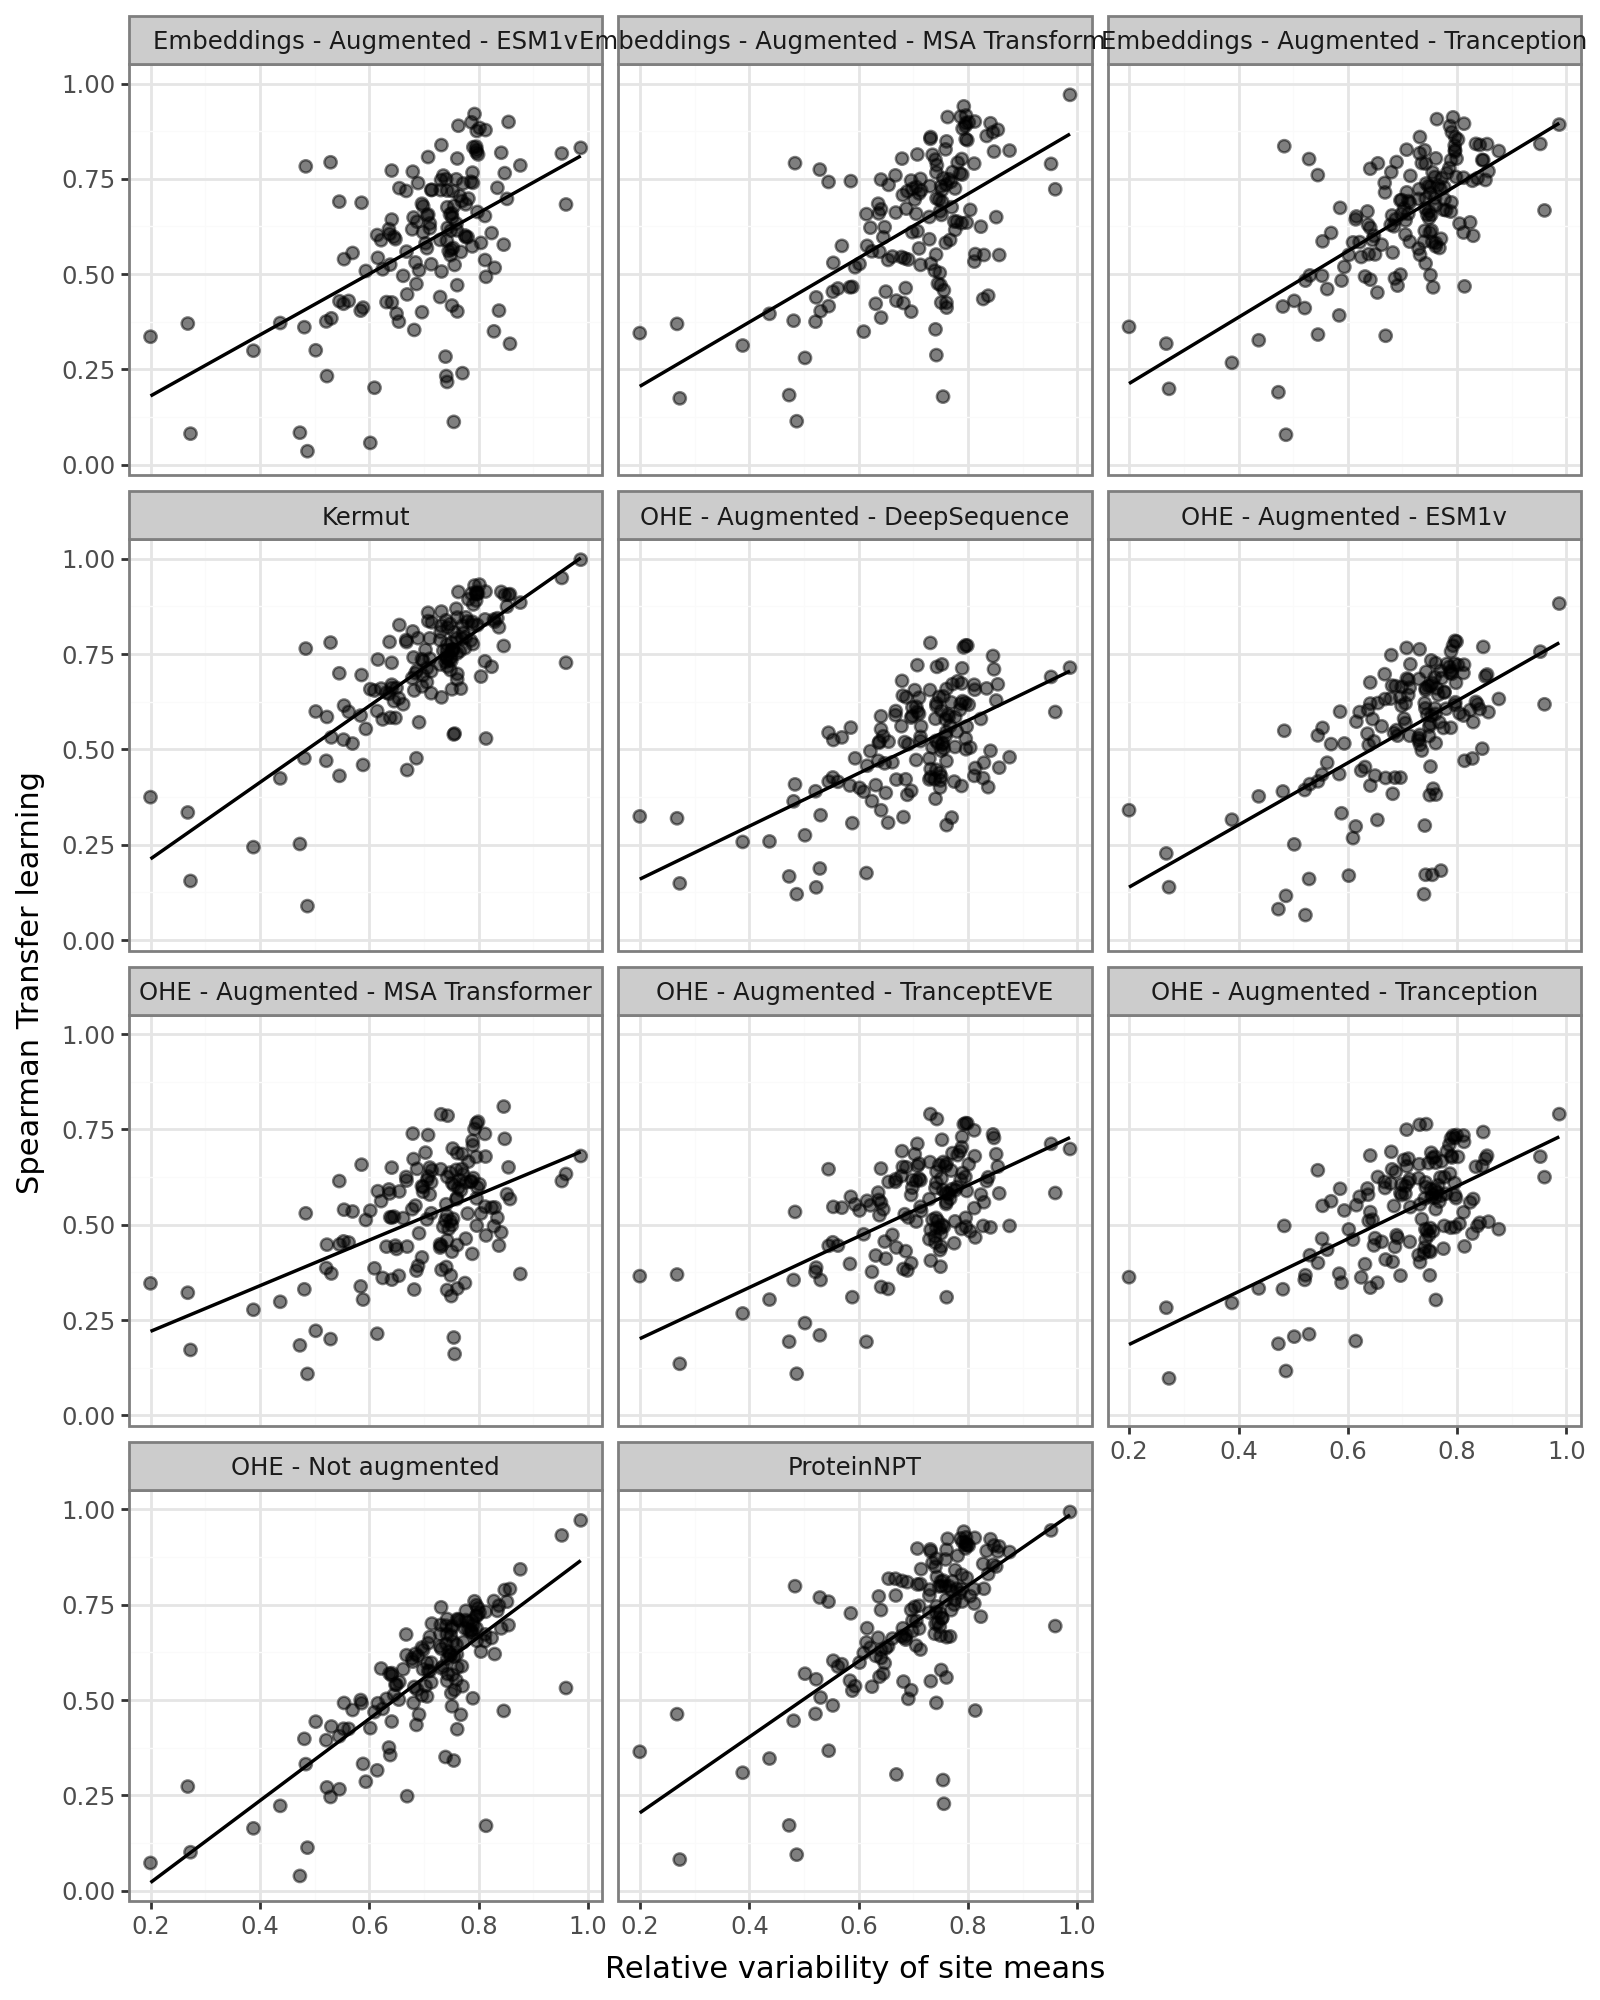

In [17]:
(
    pln.ggplot(res, pln.aes(y='Spearman', x='RVSM'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=2, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7)
    + pln.theme_bw()
    + pln.facet_wrap('~model_name', ncol=3)
    + pln.theme(
        legend_position='top', 
        figure_size=(8, 10)
        )
    + pln.labs(
        y='Spearman Transfer learning',
        x= 'Relative variability of site means')
    )

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'fill' aesthetic. Make sure you have mapped a variable to it


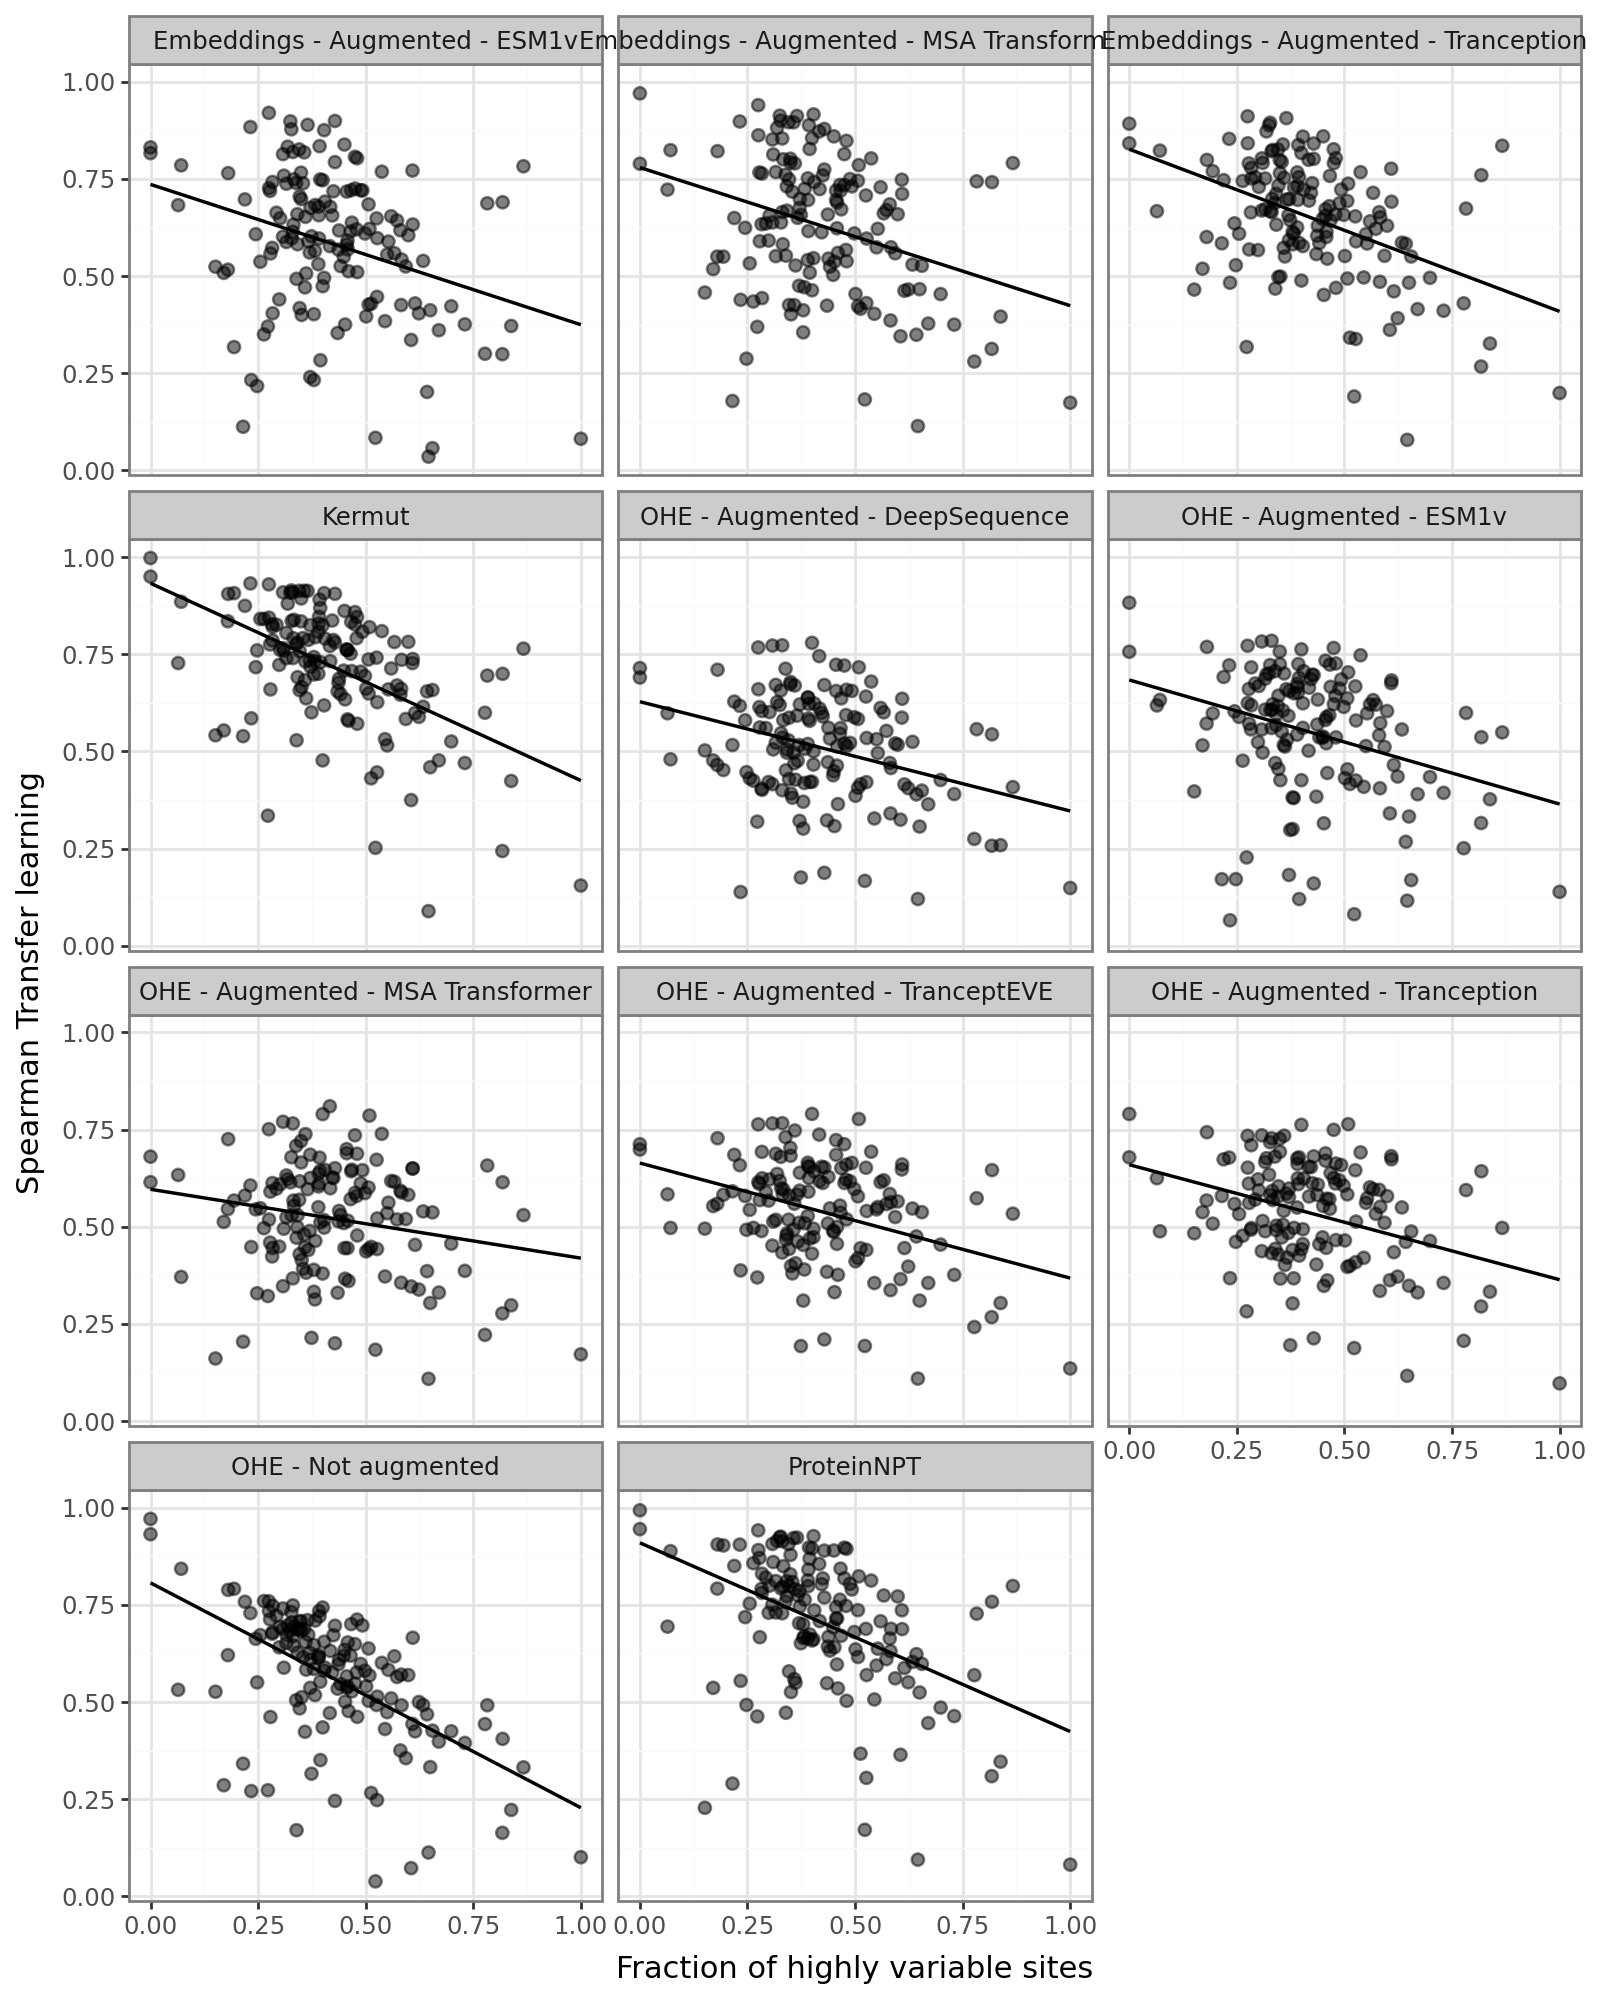

In [19]:
(
    pln.ggplot(res, pln.aes(y='Spearman', x='FHVS'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=2, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7)
    + pln.theme_bw()
    + pln.facet_wrap('~model_name', ncol=3)
    + pln.theme(
        legend_position='top', 
        figure_size=(8, 10)
        )
    + pln.labs(
        y='Spearman Transfer learning',
        x= 'Fraction of highly variable sites')
    )

In [11]:
res['model_name'].unique()

array(['Embeddings - Augmented - ESM1v',
       'Embeddings - Augmented - MSA Transformer',
       'Embeddings - Augmented - Tranception', 'Kermut',
       'OHE - Augmented - DeepSequence', 'OHE - Augmented - ESM1v',
       'OHE - Augmented - MSA Transformer',
       'OHE - Augmented - TranceptEVE', 'OHE - Augmented - Tranception',
       'OHE - Not augmented', 'ProteinNPT'], dtype=object)

In [36]:
rename_map = {
    'Embeddings - Augmented - ESM1v' : 'Emb. Aug. ESM1v', 
    'Embeddings - Augmented - MSA Transformer' : 'Emb. Aug. MSA Transformer', 
    'Embeddings - Augmented - Tranception' : 'Emb. Aug. Tranception', 
    'Embeddings - Augmented - DeepSequence' : 'Emb. Aug. DeepSequence', 
    
    'OHE - Augmented - ESM1v' : 'OHE Aug. ESM1v', 
    'OHE - Augmented - MSA Transformer' : 'OHE Aug. MSA Transformer', 
    'OHE - Augmented - Tranception' : 'OHE Aug. Tranception', 
    'OHE - Augmented - TranceptEVE' : 'OHE Aug. TranceptEVE', 
    'OHE - Augmented - DeepSequence' : 'OHE Aug. DeepSequence', 
    
    }

res['model_name'] = res['model_name'].replace(rename_map)
res

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM
2,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. ESM1v,fold_random_5,0.232439,0.933645,0.234127,0.522487
5,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. MSA Transformer,fold_random_5,0.439006,0.912103,0.234127,0.522487
8,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. Tranception,fold_random_5,0.482941,0.854068,0.234127,0.522487
11,A0A140D2T1_ZIKV_Sourisseau_2019,Kermut,fold_random_5,0.585255,0.776758,0.234127,0.522487
14,A0A140D2T1_ZIKV_Sourisseau_2019,OHE Aug. DeepSequence,fold_random_5,0.138202,1.012760,0.234127,0.522487
...,...,...,...,...,...,...,...
7049,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE Aug. MSA Transformer,fold_random_5,0.606187,0.607334,0.232143,0.801616
7052,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE Aug. TranceptEVE,fold_random_5,0.658348,0.746992,0.232143,0.801616
7055,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE Aug. Tranception,fold_random_5,0.677994,0.749584,0.232143,0.801616
7058,VRPI_BPT7_Tsuboyama_2023_2WNM,OHE - Not augmented,fold_random_5,0.728991,0.673653,0.232143,0.801616


# Predicting dataset success with variability metrics

In [21]:
# top models from protein gym
res.groupby(['model_name'], as_index=False)['Spearman'].mean().sort_values('Spearman', ascending=False)

,model_name,Spearman
3,Kermut,0.716920
10,ProteinNPT,0.703288
2,Emb. Aug. Tranception,0.649103
1,Emb. Aug. MSA Transformer,0.628285
0,Emb. Aug. ESM1v,0.582490
4,OHE - Not augmented,0.560699
6,OHE Aug. ESM1v,0.548127
8,OHE Aug. TranceptEVE,0.537998
9,OHE Aug. Tranception,0.533797
7,OHE Aug. MSA Transformer,0.520989


In [37]:
res['model_name'].unique()

array(['Emb. Aug. ESM1v', 'Emb. Aug. MSA Transformer',
       'Emb. Aug. Tranception', 'Kermut', 'OHE Aug. DeepSequence',
       'OHE Aug. ESM1v', 'OHE Aug. MSA Transformer',
       'OHE Aug. TranceptEVE', 'OHE Aug. Tranception',
       'OHE - Not augmented', 'ProteinNPT'], dtype=object)

## Kermut

In [23]:
res_filtered = res.query('model_name == "Kermut"').copy()
model = ols('Spearman ~ RVSM+FHVS', data=res_filtered).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Spearman   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     116.5
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           6.87e-31
Time:                        11:11:26   Log-Likelihood:                 135.83
No. Observations:                 148   AIC:                            -265.7
Df Residuals:                     145   BIC:                            -256.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1037      0.095     -1.091      0.2

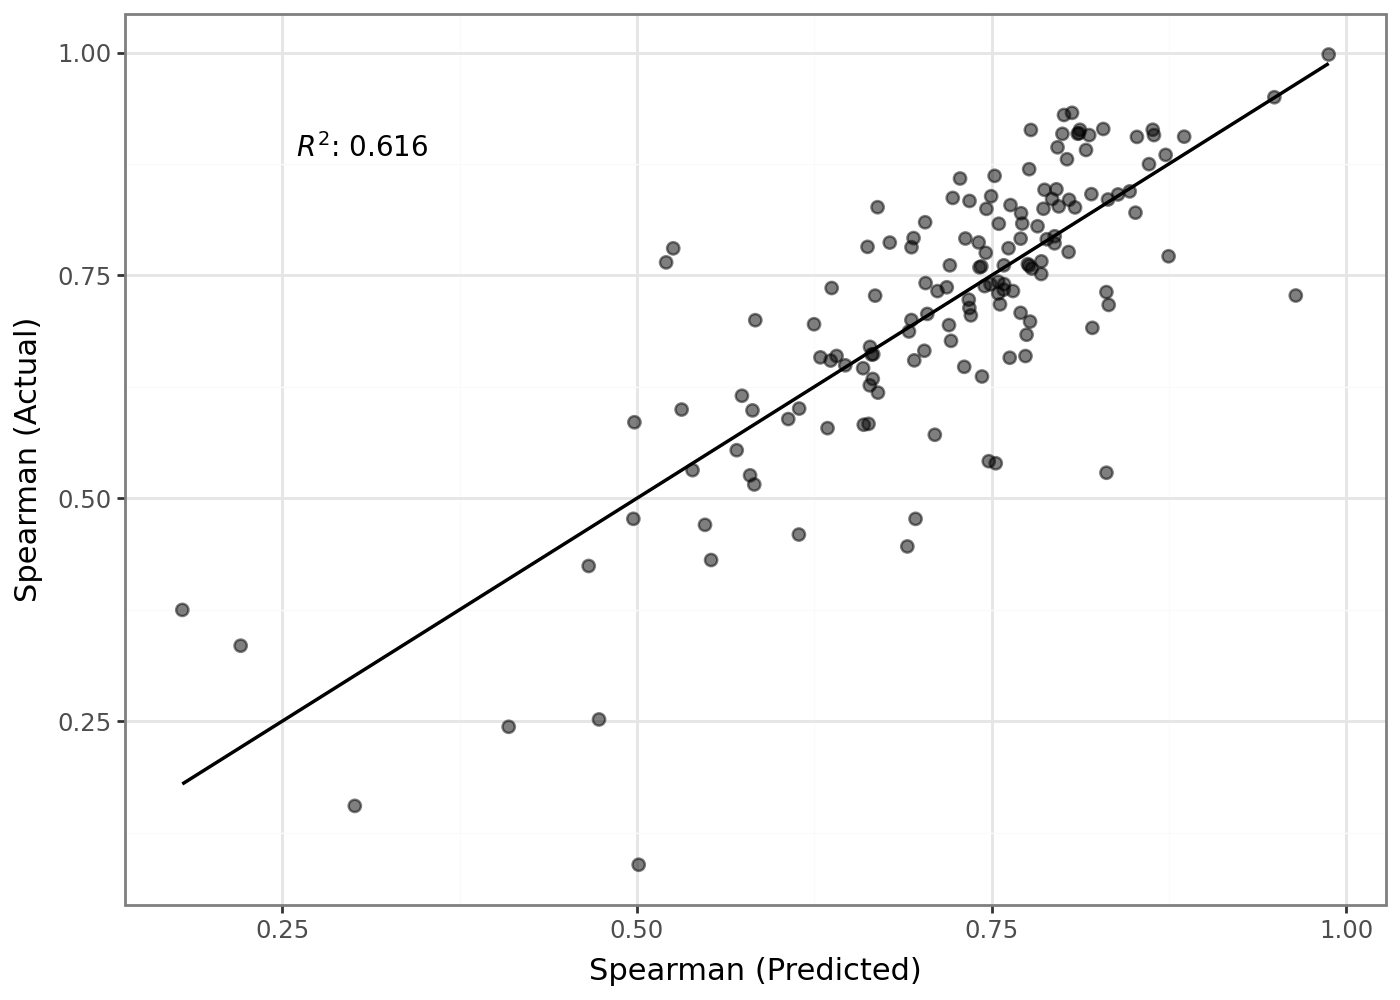

In [24]:
r2 = model.rsquared
res_filtered['y_pred'] = model.predict(res_filtered)
res_filtered['y_true'] = res_filtered['Spearman']

plot = (
    pln.ggplot(res_filtered, pln.aes(y='y_true', x='y_pred'))
    + pln.geom_point(size=2, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7)
    + pln.theme_bw()
    + pln.annotate("text", x=0.26, y=0.91, ha='left', va='top', size=10, label=f'$R^2$: {r2:.3}')
    + pln.labs(
        x='Spearman (Predicted)',
        y='Spearman (Actual)'
        )
    + pln.theme(
        legend_position='top', 
        figure_size=(7, 5)
        )
    )

plot#.save('../experiments/actual_x_predicted_protGym.png', dpi=600)

In [26]:
res_df = pd.DataFrame()
for model in ["ProteinNPT", "Emb. Aug. Tranception", "Emb. Aug. MSA Transformer", "Emb. Aug. ESM1v"]:
    res_filtered = res.query('model_name == @model').copy()
    model = ols('Spearman ~ RVSM+FHVS', data=res_filtered).fit()

    r2 = model.rsquared
    res_filtered['y_pred'] = model.predict(res_filtered)
    res_filtered['y_true'] = res_filtered['Spearman']
    res_filtered['annotation'] = round(r2,3)
    res_df = pd.concat([res_df, res_filtered])

res_df['model_name'] = pd.Categorical(res_df['model_name'], categories= ["ProteinNPT", "Emb. Aug. Tranception", "Emb. Aug. MSA Transformer", "Emb. Aug. ESM1v"])
res_df

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM,y_pred,y_true,annotation
32,A0A140D2T1_ZIKV_Sourisseau_2019,ProteinNPT,fold_random_5,0.554548,0.841689,0.234127,0.522487,0.472609,0.554548,0.485
65,A0A192B1T2_9HIV1_Haddox_2018,ProteinNPT,fold_random_5,0.792018,0.363526,0.179758,0.829449,0.812852,0.792018,0.485
98,A0A1I9GEU1_NEIME_Kennouche_2019,ProteinNPT,fold_random_5,0.094391,1.486633,0.645963,0.486831,0.489950,0.094391,0.485
131,A0A247D711_LISMN_Stadelmann_2021,ProteinNPT,fold_random_5,0.642806,0.547351,0.436782,0.705409,0.708322,0.642806,0.485
164,A0A2Z5U3Z0_9INFA_Doud_2016,ProteinNPT,fold_random_5,0.792348,0.370140,0.328014,0.779972,0.777570,0.792348,0.485
...,...,...,...,...,...,...,...,...,...,...
6833,UBE4B_MOUSE_Starita_2013,Emb. Aug. ESM1v,fold_random_5,0.510280,0.708507,0.480392,0.691017,0.581283,0.510280,0.276
6899,VG08_BPP22_Tsuboyama_2023_2GP8,Emb. Aug. ESM1v,fold_random_5,0.898322,0.168482,0.325000,0.786835,0.647195,0.898322,0.276
6965,VKOR1_HUMAN_Chiasson_2020_abundance,Emb. Aug. ESM1v,fold_random_5,0.725538,0.425550,0.475309,0.655011,0.545079,0.725538,0.276
6998,VKOR1_HUMAN_Chiasson_2020_activity,Emb. Aug. ESM1v,fold_random_5,0.446746,0.743680,0.526316,0.669228,0.568202,0.446746,0.276


In [27]:
ann = (
    res_df
    .groupby('model_name', as_index=False)
    .first()[['model_name', 'annotation']]
)


ann['r2_label'] = ann['annotation'].apply(lambda v: f"R² = {v:.3f}")
ann

/tmp/ipykernel_3882449/1780263550.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,model_name,annotation,r2_label
0,ProteinNPT,0.485,R² = 0.485
1,Emb. Aug. Tranception,0.474,R² = 0.474
2,Emb. Aug. MSA Transformer,0.346,R² = 0.346
3,Emb. Aug. ESM1v,0.276,R² = 0.276


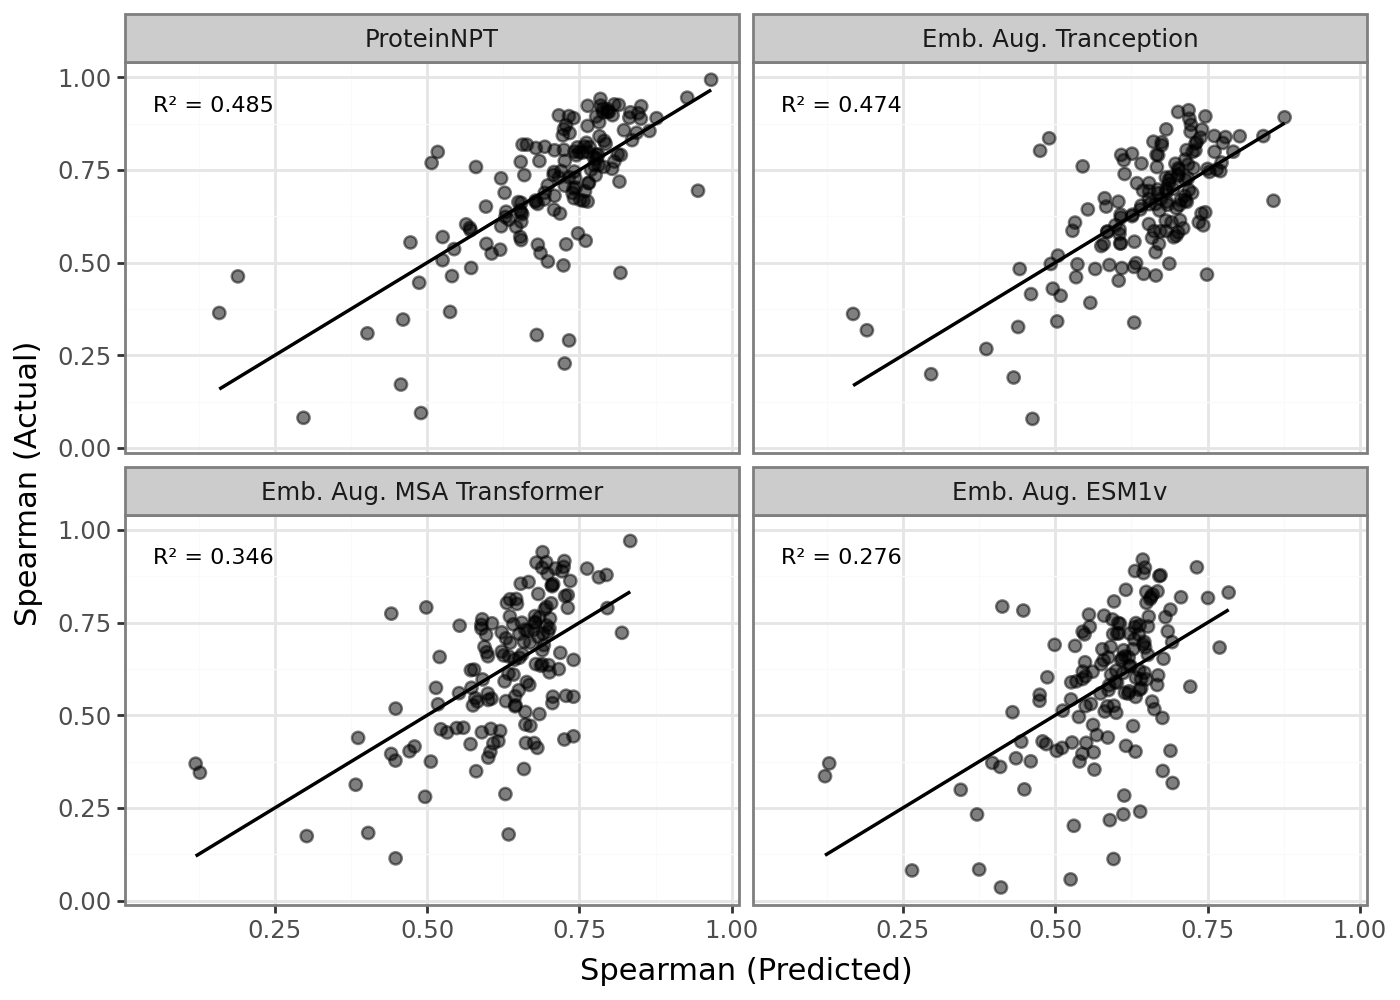

In [28]:
p1 = (
    pln.ggplot(res_df, pln.aes(y='y_true', x='y_pred'))
    + pln.geom_point(size=2, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7)
    + pln.theme_bw()
    + pln.facet_wrap('~model_name', ncol=2)
    + pln.labs(
        x='Spearman (Predicted)',
        y='Spearman (Actual)'
        )
    + pln.theme(
        legend_position='top', 
        figure_size=(7, 5)
        )
    + pln.geom_text(
        size=8,
        data=ann,
        mapping=pln.aes(x=0.05, y=0.95, label='r2_label'),
        ha='left', va='top',
        inherit_aes=False
    )
)

p1#.save('../experiments/top5_actual_x_predicted_protGym.png', dpi=600)

# ranking model by success

In [39]:
models = ['Emb. Aug. ESM1v', 'Emb. Aug. MSA Transformer',
       'Emb. Aug. Tranception', 'Kermut', 'OHE Aug. DeepSequence',
       'OHE Aug. ESM1v', 'OHE Aug. MSA Transformer',
       'OHE Aug. TranceptEVE', 'OHE Aug. Tranception',
       'OHE - Not augmented', 'ProteinNPT']

res_df = pd.DataFrame()
for model in models:
    res_filtered = res.query('model_name == @model').copy()
    model = ols('Spearman ~ RVSM+FHVS', data=res_filtered).fit()

    r2 = model.rsquared
    res_filtered['y_pred'] = model.predict(res_filtered)
    res_filtered['y_true'] = res_filtered['Spearman']
    res_filtered['R2'] = round(r2,3)
    res_df = pd.concat([res_df, res_filtered])

#res_df['model_name'] = pd.Categorical(res_df['model_name'], categories= ["ProteinNPT", "Emb. Aug. Tranception", "Emb. Aug. MSA Transformer", "Emb. Aug. ESM1v"])
res_df

,DMS_id,model_name,fold_variable_name,Spearman,MSE,FHVS,RVSM,y_pred,y_true,R2
2,A0A140D2T1_ZIKV_Sourisseau_2019,Emb. Aug. ESM1v,fold_random_5,0.232439,0.933645,0.234127,0.522487,0.371744,0.232439,0.276
35,A0A192B1T2_9HIV1_Haddox_2018,Emb. Aug. ESM1v,fold_random_5,0.516591,0.740745,0.179758,0.829449,0.662793,0.516591,0.276
68,A0A1I9GEU1_NEIME_Kennouche_2019,Emb. Aug. ESM1v,fold_random_5,0.035419,1.158052,0.645963,0.486831,0.410996,0.035419,0.276
101,A0A247D711_LISMN_Stadelmann_2021,Emb. Aug. ESM1v,fold_random_5,0.568084,0.603072,0.436782,0.705409,0.587530,0.568084,0.276
134,A0A2Z5U3Z0_9INFA_Doud_2016,Emb. Aug. ESM1v,fold_random_5,0.597123,0.659659,0.328014,0.779972,0.641012,0.597123,0.276
...,...,...,...,...,...,...,...,...,...,...
6863,UBE4B_MOUSE_Starita_2013,ProteinNPT,fold_random_5,0.503174,0.805311,0.480392,0.691017,0.698129,0.503174,0.485
6929,VG08_BPP22_Tsuboyama_2023_2GP8,ProteinNPT,fold_random_5,0.923944,0.129867,0.325000,0.786835,0.784925,0.923944,0.485
6995,VKOR1_HUMAN_Chiasson_2020_abundance,ProteinNPT,fold_random_5,0.818443,0.294428,0.475309,0.655011,0.656612,0.818443,0.485
7028,VKOR1_HUMAN_Chiasson_2020_activity,ProteinNPT,fold_random_5,0.304887,1.063758,0.526316,0.669228,0.679876,0.304887,0.485


In [42]:
cols = ['Spearman', 'R2']
success_df = res_df.groupby(['model_name'], as_index=False)[cols].mean()
success_df

,model_name,Spearman,R2
0,Emb. Aug. ESM1v,0.582490,0.276
1,Emb. Aug. MSA Transformer,0.628285,0.346
2,Emb. Aug. Tranception,0.649103,0.474
3,Kermut,0.716920,0.616
4,OHE - Not augmented,0.560699,0.625
5,OHE Aug. DeepSequence,0.508385,0.403
6,OHE Aug. ESM1v,0.548127,0.391
7,OHE Aug. MSA Transformer,0.520989,0.323
8,OHE Aug. TranceptEVE,0.537998,0.386
9,OHE Aug. Tranception,0.533797,0.403


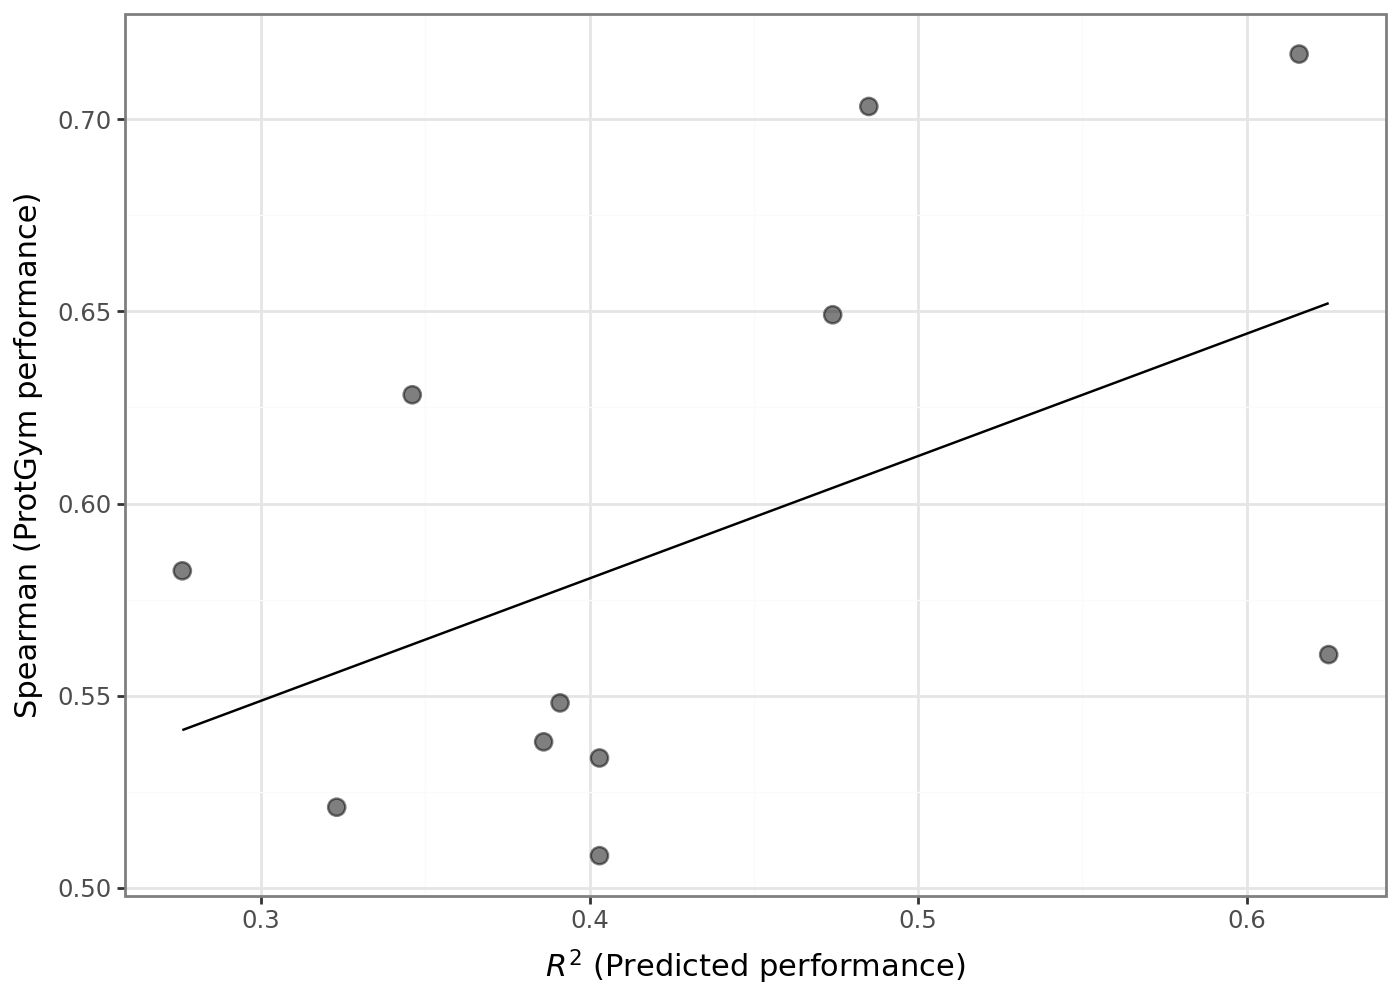

In [49]:
plot = (
    pln.ggplot(success_df, pln.aes(y='Spearman', x='R2'))
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.5)
    + pln.theme_bw()
    + pln.labs(
        y='Spearman (ProtGym performance)',
        x='$R^2$ (Predicted performance)',
        )
    + pln.theme(
        legend_position='top', 
        figure_size=(7, 5)
        )
    )

plot#.save('../experiments/figures/supp6_predicting_performance.png', dpi=600)